# FinQA Dataset Analysis
Statistics and characteristics of the FinQA dataset (train/dev/test splits).

In [1]:
import json
import re
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / '.env', override=True)

DATA_DIR = Path.cwd().parent / 'data'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Load Data

In [2]:
splits = {}
for name in ['train', 'dev', 'test']:
    path = DATA_DIR / f'{name}.json'
    if path.exists():
        with open(path) as f:
            splits[name] = json.load(f)
        print(f'{name}: {len(splits[name])} examples')
    else:
        print(f'{name}: NOT FOUND')

print(f'\nTotal: {sum(len(v) for v in splits.values())} examples')

train: 6251 examples
dev: 883 examples
test: 1147 examples

Total: 8281 examples


## 2. Basic Statistics

In [3]:
rows = []
for split_name, data in splits.items():
    for entry in data:
        qa = entry.get('qa', {})
        table = entry.get('table', [])
        pre_text = entry.get('pre_text', [])
        post_text = entry.get('post_text', [])
        program = qa.get('program', '')
        steps = qa.get('steps', [])
        
        # Count operations in program
        ops = re.findall(r'(\w+)\(', program)
        
        rows.append({
            'split': split_name,
            'id': entry.get('id', ''),
            'question': qa.get('question', ''),
            'question_len': len(qa.get('question', '').split()),
            'answer': qa.get('answer', ''),
            'program': program,
            'exe_ans': qa.get('exe_ans'),
            'num_steps': len(steps),
            'num_ops': len(ops),
            'ops': ops,
            'table_rows': len(table),
            'table_cols': len(table[0]) if table else 0,
            'num_pre_text': len(pre_text),
            'num_post_text': len(post_text),
            'total_text_sents': len(pre_text) + len(post_text),
            'filename': entry.get('filename', ''),
        })

df = pd.DataFrame(rows)
print(f'DataFrame: {len(df)} rows, {len(df.columns)} columns')
df.head()

DataFrame: 8281 rows, 16 columns


,split,id,question,question_len,answer,program,exe_ans,num_steps,num_ops,ops,table_rows,table_cols,num_pre_text,num_post_text,total_text_sents,filename
0,train,ADI/2009/page_49.pdf-1,what is the the interest expense in 2009?,8,380,"divide(100, 100), divide(3.8, #0)",3.8,2,2,"[divide, divide]",4,3,15,35,50,ADI/2009/page_49.pdf
1,train,ABMD/2012/page_75.pdf-1,"during the 2012 year , did the equity awards i...",29,,"multiply(607, 18.13), multiply(#0, const_1000)...",yes,4,4,"[multiply, multiply, multiply, greater]",6,3,3,15,18,ABMD/2012/page_75.pdf
2,train,AAL/2018/page_13.pdf-2,what was the total operating expenses in 2018 ...,10,41932,"divide(9896, 23.6%)",41932.20339,1,1,[divide],4,5,2,17,19,AAL/2018/page_13.pdf
3,train,INTC/2013/page_71.pdf-4,what percentage of total cash and investments ...,18,53%,"divide(14001, 26302)",0.53232,1,1,[divide],9,3,10,4,14,INTC/2013/page_71.pdf
4,train,ETR/2008/page_313.pdf-3,what is the growth rate in net revenue in 2008?,10,-3.2%,"subtract(959.2, 991.1), divide(#0, 991.1)",-0.03219,2,2,"[subtract, divide]",7,2,3,9,12,ETR/2008/page_313.pdf


In [4]:
# Summary stats per split
summary = df.groupby('split').agg(
    count=('id', 'count'),
    avg_question_len=('question_len', 'mean'),
    avg_num_steps=('num_steps', 'mean'),
    avg_num_ops=('num_ops', 'mean'),
    avg_table_rows=('table_rows', 'mean'),
    avg_table_cols=('table_cols', 'mean'),
    avg_text_sents=('total_text_sents', 'mean'),
).round(2)
summary

,count,avg_question_len,avg_num_steps,avg_num_ops,avg_table_rows,avg_table_cols,avg_text_sents
split,,,,,,,
dev,883,16.41,1.54,1.54,6.27,3.94,24.12
test,1147,16.72,1.54,1.54,6.55,3.92,24.71
train,6251,16.65,1.54,1.54,6.34,3.84,24.27


## 3. Question Analysis

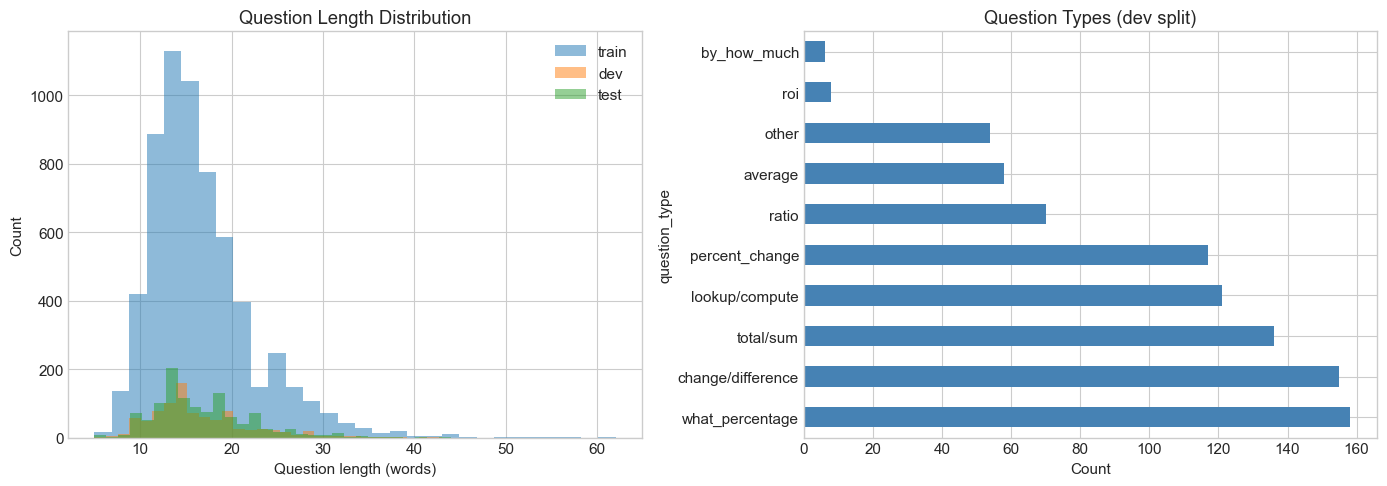


Question type distribution across splits:


question_type,average,by_how_much,change/difference,lookup/compute,other,percent_change,ratio,roi,total/sum,what_percentage
split,,,,,,,,,,
dev,58,6,155,121,54,117,70,8,136,158
test,67,7,179,161,53,179,90,15,174,222
train,403,66,1067,809,309,862,506,57,929,1243


In [5]:
# Question length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split_name in splits:
    subset = df[df['split'] == split_name]
    axes[0].hist(subset['question_len'], bins=30, alpha=0.5, label=split_name)
axes[0].set_xlabel('Question length (words)')
axes[0].set_ylabel('Count')
axes[0].set_title('Question Length Distribution')
axes[0].legend()

# Question type classification by keyword
def classify_question(q):
    q = q.lower()
    if 'percent change' in q or 'percentage change' in q or 'growth rate' in q:
        return 'percent_change'
    elif 'by how much' in q:
        return 'by_how_much'
    elif 'what percentage' in q or 'what portion' in q or '% of' in q or 'what percent' in q:
        return 'what_percentage'
    elif 'ratio' in q:
        return 'ratio'
    elif 'change' in q or 'difference' in q or 'increase' in q or 'decrease' in q:
        return 'change/difference'
    elif 'total' in q or 'sum' in q or 'combined' in q:
        return 'total/sum'
    elif 'average' in q or 'mean' in q:
        return 'average'
    elif 'roi' in q or 'return on' in q:
        return 'roi'
    elif 'what was' in q or 'what is' in q or 'what are' in q:
        return 'lookup/compute'
    else:
        return 'other'

df['question_type'] = df['question'].apply(classify_question)
type_counts = df.groupby(['split', 'question_type']).size().unstack(fill_value=0)

# Plot for dev split
dev_types = df[df['split'] == 'dev']['question_type'].value_counts()
dev_types.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Count')
axes[1].set_title('Question Types (dev split)')

plt.tight_layout()
plt.show()

print('\nQuestion type distribution across splits:')
type_counts

## 4. Program / Operation Analysis

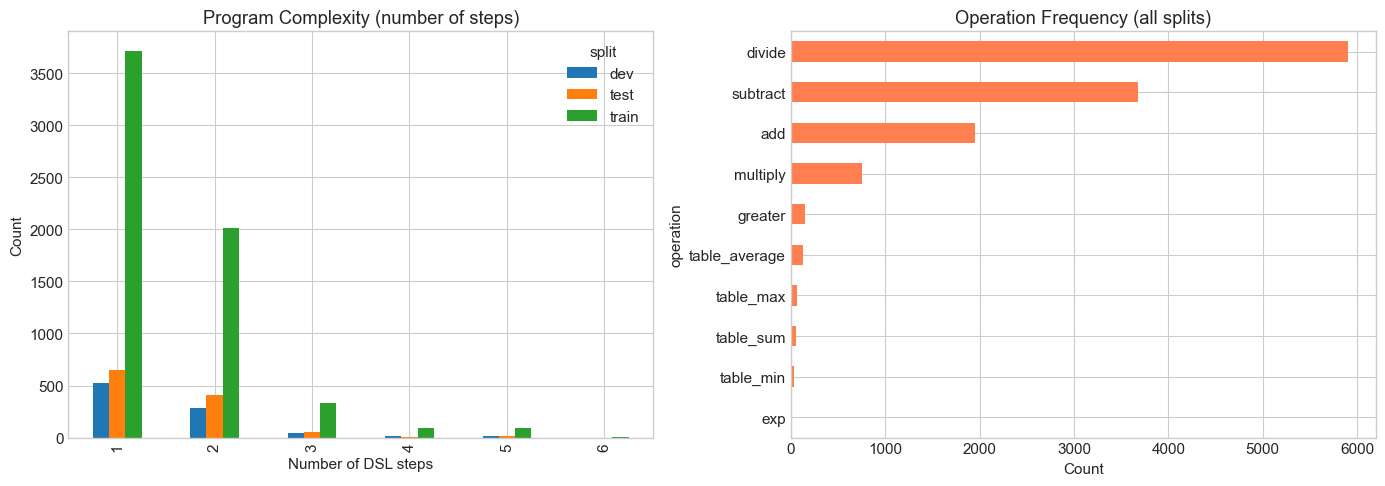


Operation frequency:


,operation,count
0,divide,5901
1,subtract,3676
2,add,1952
3,multiply,759
4,greater,154
5,table_average,129
6,table_max,66
7,table_sum,50
8,table_min,36
9,exp,9


In [6]:
# Number of steps distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step_counts = df.groupby(['split', 'num_steps']).size().unstack(level=0, fill_value=0)
step_counts.plot.bar(ax=axes[0])
axes[0].set_xlabel('Number of DSL steps')
axes[0].set_ylabel('Count')
axes[0].set_title('Program Complexity (number of steps)')

# Operation frequency
all_ops = []
for ops_list in df['ops']:
    all_ops.extend(ops_list)

op_freq = Counter(all_ops).most_common()
op_df = pd.DataFrame(op_freq, columns=['operation', 'count'])
op_df.plot.barh(x='operation', y='count', ax=axes[1], color='coral', legend=False)
axes[1].set_xlabel('Count')
axes[1].set_title('Operation Frequency (all splits)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nOperation frequency:')
op_df

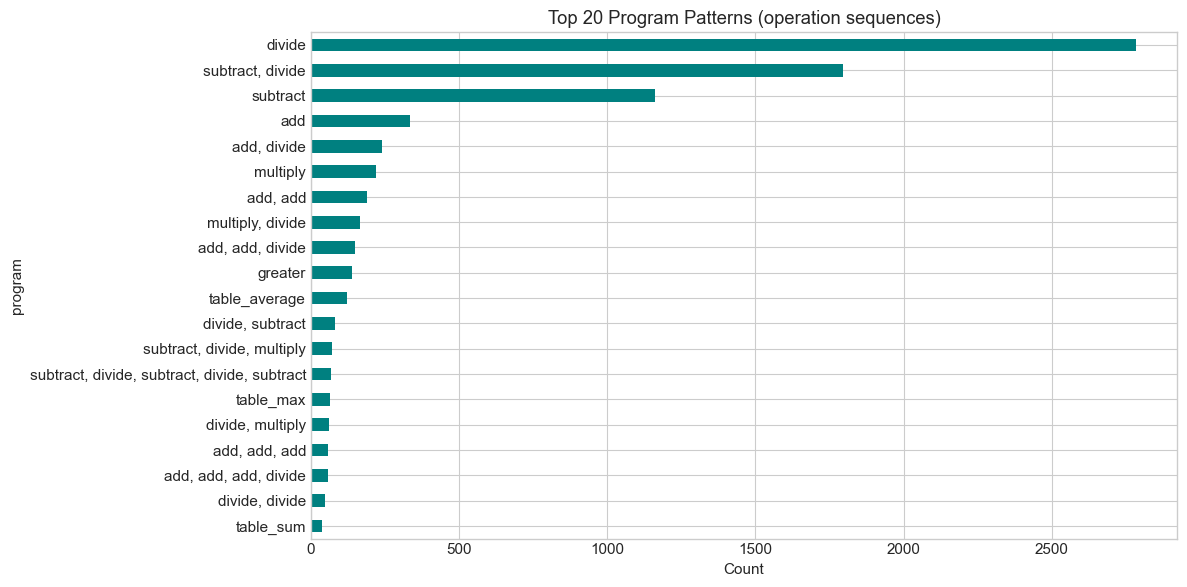


Top 20 program patterns:
  divide                                                        2783 (33.6%)
  subtract, divide                                              1795 (21.7%)
  subtract                                                      1161 (14.0%)
  add                                                            335 (4.0%)
  add, divide                                                    240 (2.9%)
  multiply                                                       220 (2.7%)
  add, add                                                       188 (2.3%)
  multiply, divide                                               167 (2.0%)
  add, add, divide                                               150 (1.8%)
  greater                                                        138 (1.7%)
  table_average                                                  123 (1.5%)
  divide, subtract                                                80 (1.0%)
  subtract, divide, multiply                               

In [7]:
# Most common program patterns (top 20)
program_patterns = df['program'].apply(
    lambda p: ', '.join(re.findall(r'(\w+)\(', p)) if p else 'EMPTY'
)
pattern_counts = program_patterns.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
pattern_counts.plot.barh(ax=ax, color='teal')
ax.set_xlabel('Count')
ax.set_title('Top 20 Program Patterns (operation sequences)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 20 program patterns:')
for pat, cnt in pattern_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {pat:<60s} {cnt:>5d} ({pct:.1f}%)')

## 5. Table Characteristics

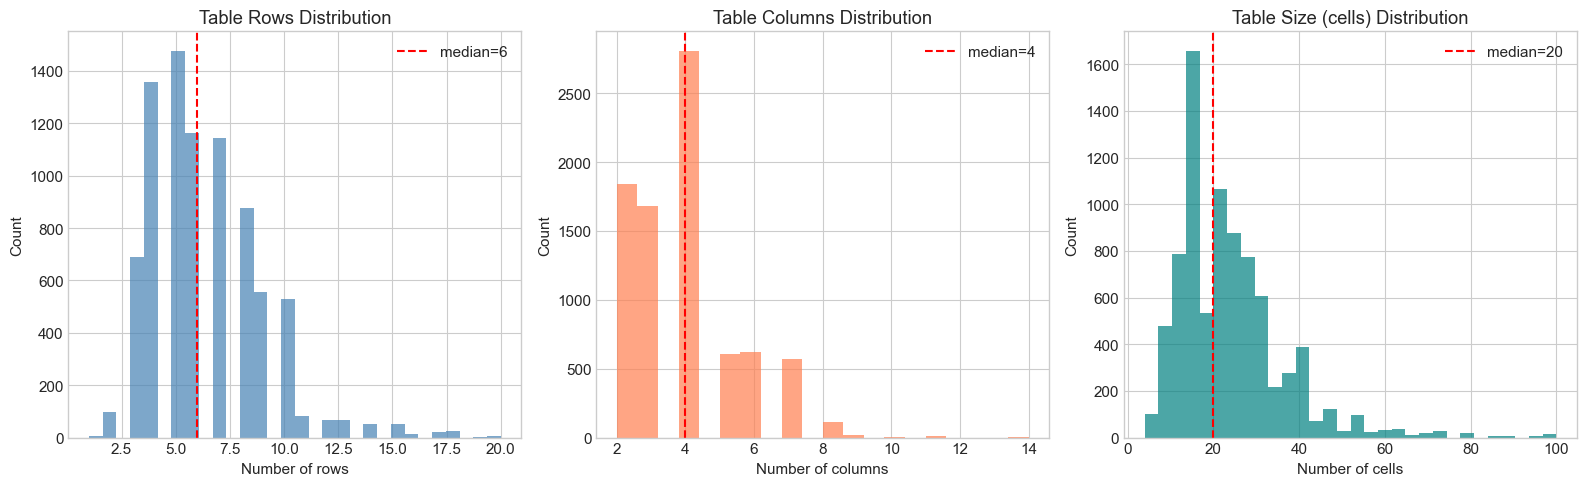

Table rows:  min=1, median=6, mean=6.4, max=20
Table cols:  min=2, median=4, mean=3.9, max=14
Table cells: min=4, median=20, mean=23.7, max=165


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Table rows distribution
df['table_rows'].clip(upper=30).hist(bins=30, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Number of rows')
axes[0].set_ylabel('Count')
axes[0].set_title('Table Rows Distribution')
axes[0].axvline(df['table_rows'].median(), color='red', linestyle='--', label=f'median={df["table_rows"].median():.0f}')
axes[0].legend()

# Table columns distribution
df['table_cols'].hist(bins=20, ax=axes[1], color='coral', alpha=0.7)
axes[1].set_xlabel('Number of columns')
axes[1].set_ylabel('Count')
axes[1].set_title('Table Columns Distribution')
axes[1].axvline(df['table_cols'].median(), color='red', linestyle='--', label=f'median={df["table_cols"].median():.0f}')
axes[1].legend()

# Table size (rows * cols)
df['table_cells'] = df['table_rows'] * df['table_cols']
df['table_cells'].clip(upper=100).hist(bins=30, ax=axes[2], color='teal', alpha=0.7)
axes[2].set_xlabel('Number of cells')
axes[2].set_ylabel('Count')
axes[2].set_title('Table Size (cells) Distribution')
axes[2].axvline(df['table_cells'].median(), color='red', linestyle='--', label=f'median={df["table_cells"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Table rows:  min={df["table_rows"].min()}, median={df["table_rows"].median():.0f}, mean={df["table_rows"].mean():.1f}, max={df["table_rows"].max()}')
print(f'Table cols:  min={df["table_cols"].min()}, median={df["table_cols"].median():.0f}, mean={df["table_cols"].mean():.1f}, max={df["table_cols"].max()}')
print(f'Table cells: min={df["table_cells"].min()}, median={df["table_cells"].median():.0f}, mean={df["table_cells"].mean():.1f}, max={df["table_cells"].max()}')

## 6. Text Context Analysis

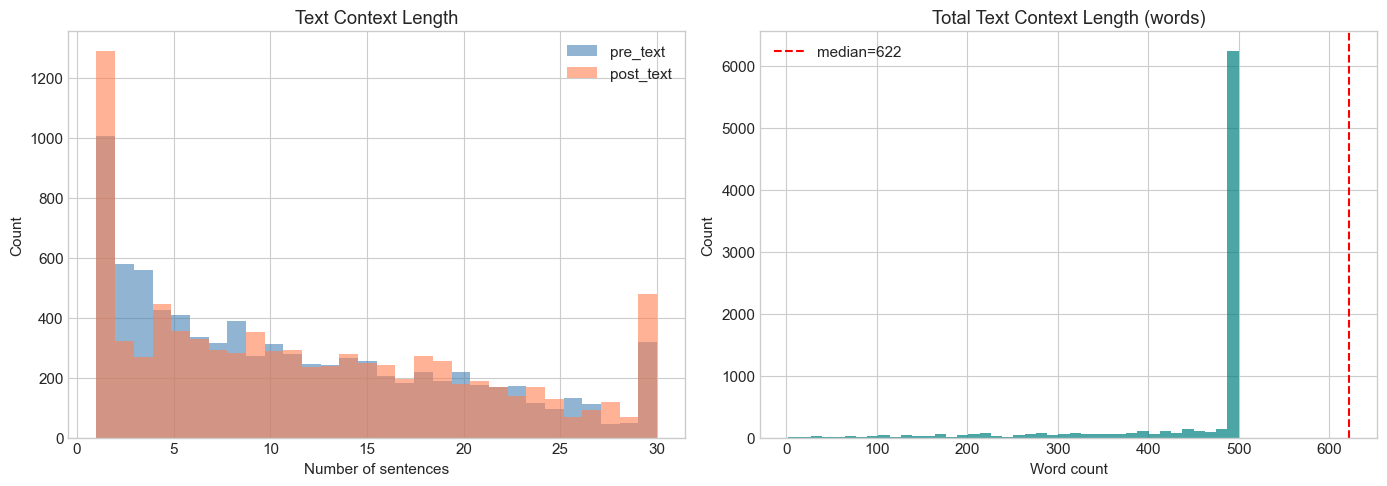

Pre-text sentences:  mean=11.6, median=9
Post-text sentences: mean=12.7, median=10
Total text words:    mean=628, median=622


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre-text and post-text sentence counts
df['num_pre_text'].clip(upper=30).hist(bins=30, ax=axes[0], alpha=0.6, label='pre_text', color='steelblue')
df['num_post_text'].clip(upper=30).hist(bins=30, ax=axes[0], alpha=0.6, label='post_text', color='coral')
axes[0].set_xlabel('Number of sentences')
axes[0].set_ylabel('Count')
axes[0].set_title('Text Context Length')
axes[0].legend()

# Total text word count
def count_text_words(entry):
    pre = ' '.join(entry.get('pre_text', []))
    post = ' '.join(entry.get('post_text', []))
    return len((pre + ' ' + post).split())

text_words = []
for split_name, data in splits.items():
    for entry in data:
        text_words.append({'split': split_name, 'word_count': count_text_words(entry)})

tw_df = pd.DataFrame(text_words)
tw_df['word_count'].clip(upper=500).hist(bins=40, ax=axes[1], color='teal', alpha=0.7)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Count')
axes[1].set_title('Total Text Context Length (words)')
axes[1].axvline(tw_df['word_count'].median(), color='red', linestyle='--', label=f'median={tw_df["word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Pre-text sentences:  mean={df["num_pre_text"].mean():.1f}, median={df["num_pre_text"].median():.0f}')
print(f'Post-text sentences: mean={df["num_post_text"].mean():.1f}, median={df["num_post_text"].median():.0f}')
print(f'Total text words:    mean={tw_df["word_count"].mean():.0f}, median={tw_df["word_count"].median():.0f}')

## 7. Answer Distribution

Numeric answers: 8127 (98.1%)
Non-numeric answers: 154 (1.9%)
  Non-numeric values: {'yes': 93, 'no': 61}


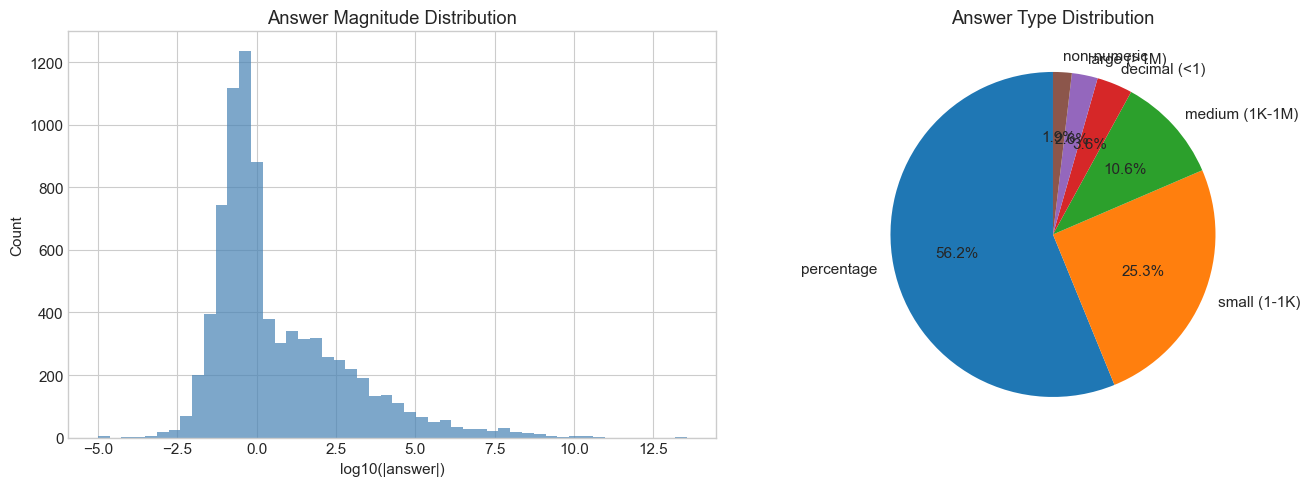

In [10]:
# Answer value analysis
numeric_answers = df[df['exe_ans'].apply(lambda x: isinstance(x, (int, float)))].copy()
non_numeric = df[~df['exe_ans'].apply(lambda x: isinstance(x, (int, float)))]

print(f'Numeric answers: {len(numeric_answers)} ({len(numeric_answers)/len(df)*100:.1f}%)')
print(f'Non-numeric answers: {len(non_numeric)} ({len(non_numeric)/len(df)*100:.1f}%)')
if len(non_numeric) > 0:
    print(f'  Non-numeric values: {non_numeric["exe_ans"].value_counts().head(10).to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of answer magnitudes (log scale)
abs_ans = numeric_answers['exe_ans'].astype(float).abs().replace(0, np.nan).dropna()
log_ans = np.log10(abs_ans.to_numpy())
axes[0].hist(log_ans, bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('log10(|answer|)')
axes[0].set_ylabel('Count')
axes[0].set_title('Answer Magnitude Distribution')

# Percentage vs absolute answers
def answer_type(row):
    ans = row['exe_ans']
    answer_text = str(row['answer']).lower()
    if not isinstance(ans, (int, float)):
        return 'non-numeric'
    if '%' in answer_text:
        return 'percentage'
    if abs(ans) < 1 and ans != 0:
        return 'decimal (<1)'
    if abs(ans) > 1000000:
        return 'large (>1M)'
    if abs(ans) > 1000:
        return 'medium (1K-1M)'
    return 'small (1-1K)'

df['answer_type'] = df.apply(answer_type, axis=1)
at_counts = df['answer_type'].value_counts()
at_counts.plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Answer Type Distribution')

plt.tight_layout()
plt.show()

## 8. Complexity Analysis

In [11]:
# Cross-tabulation: question type vs program complexity
complexity_by_type = df.groupby('question_type').agg(
    count=('id', 'count'),
    avg_steps=('num_steps', 'mean'),
    max_steps=('num_steps', 'max'),
    avg_question_len=('question_len', 'mean'),
    avg_table_rows=('table_rows', 'mean'),
).round(2).sort_values('count', ascending=False)

print('Complexity by question type:')
complexity_by_type

Complexity by question type:


,count,avg_steps,max_steps,avg_question_len,avg_table_rows
question_type,,,,,
what_percentage,1623,1.28,5,15.16,6.75
change/difference,1401,1.58,6,17.97,6.27
total/sum,1239,1.54,5,17.90,6.36
percent_change,1158,1.99,6,15.28,6.64
lookup/compute,1091,1.33,5,16.53,5.92
ratio,666,1.24,5,18.75,6.17
average,528,2.04,6,15.45,6.18
other,416,1.38,5,16.72,6.40
roi,80,1.84,2,15.76,4.95


In [12]:
# Which operations co-occur?
from itertools import combinations

op_pairs = Counter()
for ops_list in df['ops']:
    unique_ops = set(ops_list)
    for pair in combinations(sorted(unique_ops), 2):
        op_pairs[pair] += 1

print('Top operation co-occurrences:')
for pair, cnt in op_pairs.most_common(15):
    print(f'  {pair[0]} + {pair[1]}: {cnt}')

Top operation co-occurrences:
  divide + subtract: 2127
  add + divide: 528
  divide + multiply: 368
  multiply + subtract: 148
  add + multiply: 58
  add + subtract: 56
  greater + multiply: 7
  divide + table_sum: 6
  divide + exp: 6
  divide + greater: 5
  exp + subtract: 5
  subtract + table_average: 4
  add + exp: 4
  exp + multiply: 4
  subtract + table_max: 3


## 9. Evidence Source & Fact Analysis (FinQA Paper Stats)
Analysis of where gold evidence comes from (text vs table), number of supporting facts, and distances between facts. Uses `gold_inds`, `ann_text_rows`, and `ann_table_rows` annotations.

In [13]:
# Evidence source classification and fact analysis
source_rows = []
for split_name, data in splits.items():
    for entry in data:
        qa = entry.get('qa', {})
        gi = qa.get('gold_inds', {})
        text_keys = sorted([k for k in gi if k.startswith('text_')])
        table_keys = sorted([k for k in gi if k.startswith('table_')])

        has_text = len(text_keys) > 0
        has_table = len(table_keys) > 0
        if has_text and has_table:
            source = 'both'
        elif has_text:
            source = 'text_only'
        elif has_table:
            source = 'table_only'
        else:
            source = 'none'

        num_facts = len(text_keys) + len(table_keys)

        # Max distance between facts (for multi-fact examples)
        max_dist = None
        if num_facts > 1:
            all_inds = sorted(
                [int(k.split('_')[1]) for k in text_keys] +
                [int(k.split('_')[1]) for k in table_keys]
            )
            max_dist = max(all_inds[i+1] - all_inds[i] for i in range(len(all_inds)-1))

        source_rows.append({
            'split': split_name,
            'id': entry.get('id', ''),
            'source': source,
            'num_facts': num_facts,
            'num_text_facts': len(text_keys),
            'num_table_facts': len(table_keys),
            'max_dist': max_dist,
        })

src_df = pd.DataFrame(source_rows)
n_total = len(src_df)

# --- Evidence Source ---
print('=' * 60)
print('EVIDENCE SOURCE (all splits combined)')
print('=' * 60)
for src in ['text_only', 'table_only', 'both']:
    cnt = (src_df['source'] == src).sum()
    print(f'  {src:<12s}: {cnt:>5d}  ({cnt/n_total*100:.2f}%)')

paper_src = {'text_only': 23.42, 'table_only': 62.43, 'both': 14.15}
print(f'\n  Paper reference: text_only=23.42%, table_only=62.43%, both=14.15%')

# --- Number of Facts ---
print(f'\n{"=" * 60}')
print('NUMBER OF SUPPORTING FACTS')
print('=' * 60)
fact_bins = src_df['num_facts'].apply(lambda x: '1' if x <= 1 else ('2' if x == 2 else '>2'))
for label in ['1', '2', '>2']:
    cnt = (fact_bins == label).sum()
    print(f'  {label:<4s} facts: {cnt:>5d}  ({cnt/n_total*100:.2f}%)')
print(f'\n  Paper reference: 1=46.30%, 2=42.63%, >2=11.07%')

# --- Max Distance Between Facts ---
multi = src_df[src_df['max_dist'].notna()].copy()
n_multi = len(multi)
print(f'\n{"=" * 60}')
print(f'MAX DISTANCE BETWEEN FACTS ({n_multi} multi-fact examples)')
print('=' * 60)
dist_bins = multi['max_dist'].apply(lambda x: '<=3' if x <= 3 else ('4-6' if x <= 6 else '>6'))
for label in ['<=3', '4-6', '>6']:
    cnt = (dist_bins == label).sum()
    print(f'  {label:<4s}: {cnt:>5d}  ({cnt/n_multi*100:.2f}%)')
print(f'\n  Paper reference: <=3=55.48%, 4-6=24.35%, >6=20.17%')
print(f'  Note: distance metric may differ slightly from paper')

EVIDENCE SOURCE (all splits combined)
  text_only   :  1939  (23.42%)
  table_only  :  5170  (62.43%)
  both        :  1172  (14.15%)

  Paper reference: text_only=23.42%, table_only=62.43%, both=14.15%

NUMBER OF SUPPORTING FACTS
  1    facts:  3834  (46.30%)
  2    facts:  3530  (42.63%)
  >2   facts:   917  (11.07%)

  Paper reference: 1=46.30%, 2=42.63%, >2=11.07%

MAX DISTANCE BETWEEN FACTS (4447 multi-fact examples)
  <=3 :  2719  (61.14%)
  4-6 :   953  (21.43%)
  >6  :   775  (17.43%)

  Paper reference: <=3=55.48%, 4-6=24.35%, >6=20.17%
  Note: distance metric may differ slightly from paper


## 10. Company / Source File Analysis

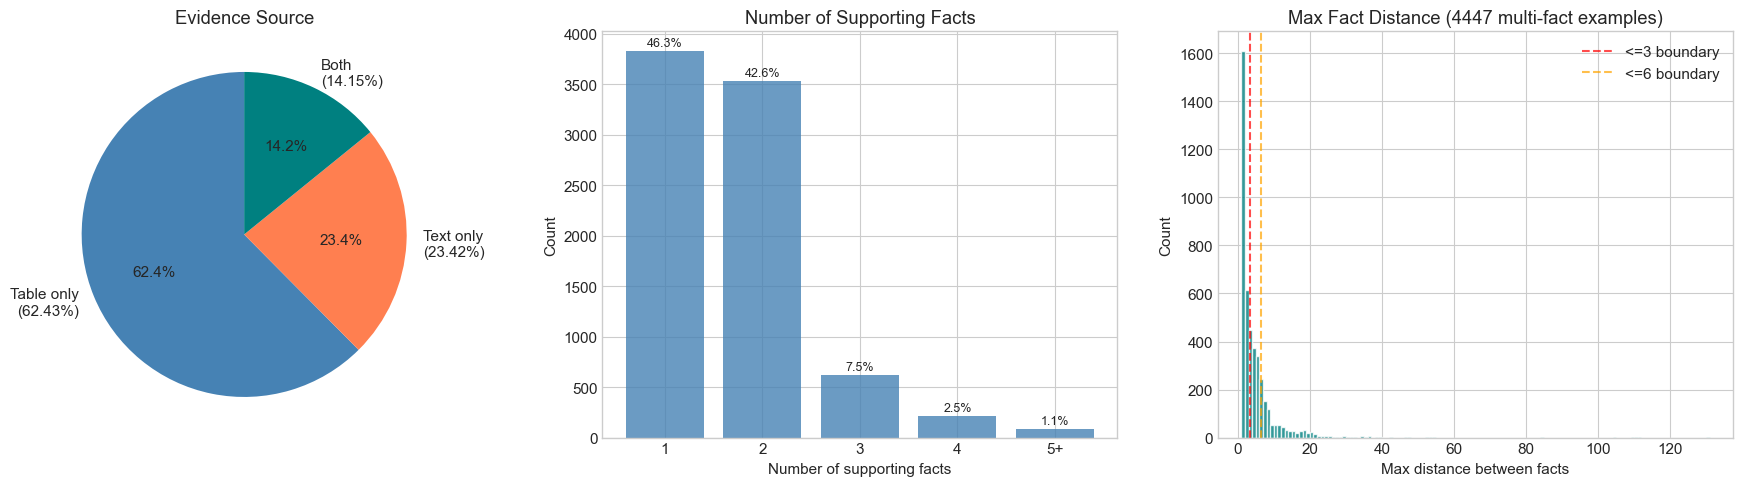


Per-split evidence source breakdown:
  train: text_only=23.3%, table_only=62.7%, both=13.9%
  dev: text_only=22.4%, table_only=61.4%, both=16.2%
  test: text_only=24.7%, table_only=61.6%, both=13.8%


In [14]:
# Visualizations for evidence source and fact analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Evidence source pie chart
src_counts = src_df['source'].value_counts()
src_labels = {'table_only': 'Table only', 'text_only': 'Text only', 'both': 'Both'}
axes[0].pie(
    [src_counts.get('table_only', 0), src_counts.get('text_only', 0), src_counts.get('both', 0)],
    labels=['Table only\n(62.43%)', 'Text only\n(23.42%)', 'Both\n(14.15%)'],
    colors=['steelblue', 'coral', 'teal'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Evidence Source')

# 2. Number of facts bar chart
fact_labels = ['1', '2', '3', '4', '5+']
fact_values = []
for label in ['1', '2', '3', '4']:
    fact_values.append((src_df['num_facts'] == int(label)).sum())
fact_values.append((src_df['num_facts'] >= 5).sum())
axes[1].bar(fact_labels, fact_values, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Number of supporting facts')
axes[1].set_ylabel('Count')
axes[1].set_title('Number of Supporting Facts')
for i, v in enumerate(fact_values):
    if v > 0:
        axes[1].text(i, v + 50, f'{v/n_total*100:.1f}%', ha='center', fontsize=9)

# 3. Max distance distribution (multi-fact only)
dist_values = multi['max_dist'].astype(int).to_numpy()
axes[2].hist(dist_values, bins=range(1, max(dist_values)+2), color='teal', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Max distance between facts')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Max Fact Distance ({n_multi} multi-fact examples)')
axes[2].axvline(3.5, color='red', linestyle='--', alpha=0.7, label='<=3 boundary')
axes[2].axvline(6.5, color='orange', linestyle='--', alpha=0.7, label='<=6 boundary')
axes[2].legend()

plt.tight_layout()
plt.show()

# Per-split breakdown
print('\nPer-split evidence source breakdown:')
for split_name in ['train', 'dev', 'test']:
    s = src_df[src_df['split'] == split_name]
    n = len(s)
    t = (s['source'] == 'text_only').sum()
    tb = (s['source'] == 'table_only').sum()
    b = (s['source'] == 'both').sum()
    print(f'  {split_name}: text_only={t/n*100:.1f}%, table_only={tb/n*100:.1f}%, both={b/n*100:.1f}%')

Unique companies: 137

Top 20 companies by example count:


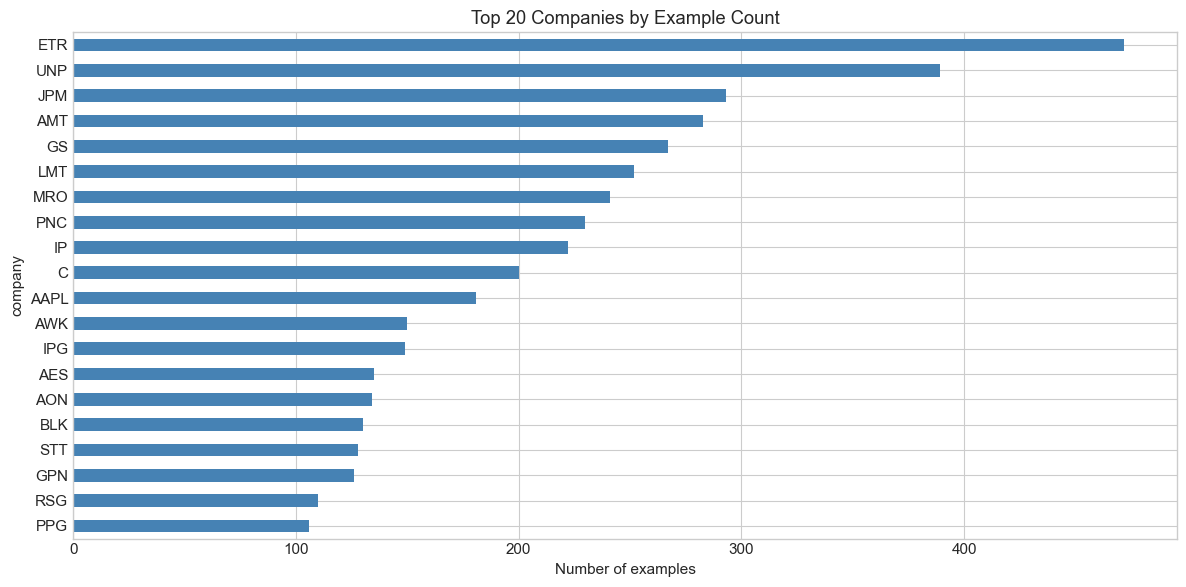

In [15]:
# Extract company ticker from entry ID (format: TICKER/YEAR/page_N.pdf-Q)
df['company'] = df['id'].apply(lambda x: x.split('/')[0] if '/' in x else 'unknown')

company_counts = df['company'].value_counts()
print(f'Unique companies: {len(company_counts)}')
print(f'\nTop 20 companies by example count:')

fig, ax = plt.subplots(figsize=(12, 6))
company_counts.head(20).plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Number of examples')
ax.set_title('Top 20 Companies by Example Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Summary

In [16]:
print('=' * 60)
print('FINQA DATASET SUMMARY')
print('=' * 60)
for split_name in ['train', 'dev', 'test']:
    if split_name in splits:
        s = df[df['split'] == split_name]
        print(f'\n{split_name.upper()} ({len(s)} examples):')
        print(f'  Questions:  avg {s["question_len"].mean():.1f} words (range {s["question_len"].min()}-{s["question_len"].max()})')
        print(f'  Programs:   avg {s["num_steps"].mean():.1f} steps (range {s["num_steps"].min()}-{s["num_steps"].max()})')
        print(f'  Tables:     avg {s["table_rows"].mean():.1f} rows x {s["table_cols"].mean():.1f} cols')
        print(f'  Context:    avg {s["total_text_sents"].mean():.1f} sentences')
        print(f'  Companies:  {s["company"].nunique()} unique')

print(f'\nOverall:')
print(f'  Unique companies: {df["company"].nunique()}')
print(f'  Unique operations: {len(set(all_ops))}')
print(f'  Most common op: {op_freq[0][0]} ({op_freq[0][1]} uses)')
print(f'  Most common pattern: {pattern_counts.index[0]} ({pattern_counts.iloc[0]} examples)')

FINQA DATASET SUMMARY

TRAIN (6251 examples):
  Questions:  avg 16.6 words (range 5-62)
  Programs:   avg 1.5 steps (range 1-6)
  Tables:     avg 6.3 rows x 3.8 cols
  Context:    avg 24.3 sentences
  Companies:  135 unique

DEV (883 examples):
  Questions:  avg 16.4 words (range 5-43)
  Programs:   avg 1.5 steps (range 1-5)
  Tables:     avg 6.3 rows x 3.9 cols
  Context:    avg 24.1 sentences
  Companies:  97 unique

TEST (1147 examples):
  Questions:  avg 16.7 words (range 5-44)
  Programs:   avg 1.5 steps (range 1-5)
  Tables:     avg 6.6 rows x 3.9 cols
  Context:    avg 24.7 sentences
  Companies:  100 unique

Overall:
  Unique companies: 137
  Unique operations: 10
  Most common op: divide (5901 uses)
  Most common pattern: divide (2783 examples)
